In [6]:
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

In [9]:
X,y = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [11]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [12]:
df.shape

(100, 3)

In [13]:
df.head()

,feature1,feature2,target
0,1.456337,-0.637187,-52.431993
1,-0.140187,1.720886,154.525747
2,-0.235959,-0.759516,39.899760
3,-0.288592,0.038871,-31.752500
4,0.226635,0.310567,-6.891262


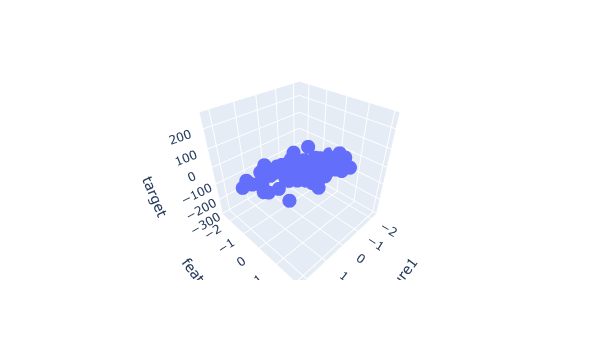

In [14]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)


In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = lr.predict(X_test)

In [31]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 37.61934970216967
MSE 2289.6656282641547
R2 score 0.7017068242099356


In [33]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

# Pehle final create karein
final = np.vstack((xGrid.ravel().reshape(1, 100), yGrid.ravel().reshape(1, 100))).T

# Phir predict karein
z_final = lr.predict(final).reshape(10, 10)
z = z_final

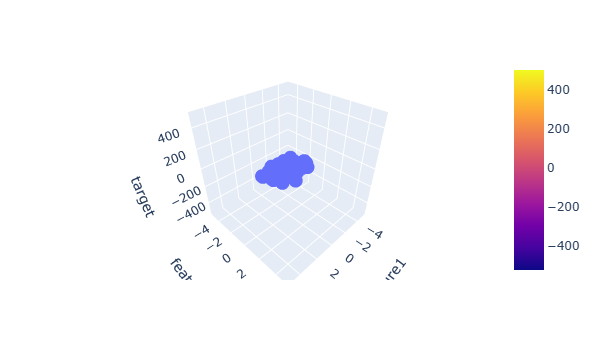

In [34]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()
     

In [35]:
lr.coef_

array([34.09801953, 68.17801598])

In [36]:
lr.intercept_

np.float64(-10.935903064654202)